### Setup

In [24]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DB_PATH = PROJECT_ROOT / "data" / "processed" / "bluestock_mf.db"

conn = sqlite3.connect(DB_PATH)

#### Rebuild nav_wide + daily_returns_trading

In [25]:
nav_long = pd.read_sql("SELECT date, amfi_code, nav FROM fact_nav", conn)
nav_long['date'] = pd.to_datetime(nav_long['date'])

nav_wide = nav_long.pivot(index='date', columns='amfi_code', values='nav').sort_index()
nav_trading = nav_wide[nav_wide.index.dayofweek < 5]

daily_returns = nav_wide.pct_change()
daily_returns_trading = daily_returns[daily_returns.index.dayofweek < 5].dropna(how='all')

print(nav_trading.shape, daily_returns_trading.shape)

(1150, 40) (1149, 40)


### 1. Historical VaR (95%) + CVaR

In [26]:
VaR_95 = daily_returns_trading.quantile(0.05)

CVaR_95 = {}
for code in daily_returns_trading.columns:
    fund_returns = daily_returns_trading[code]
    threshold = VaR_95[code]
    tail_returns = fund_returns[fund_returns <= threshold]
    CVaR_95[code] = tail_returns.mean()

CVaR_95 = pd.Series(CVaR_95)

var_cvar_df = pd.DataFrame({
    'VaR_95': VaR_95,
    'CVaR_95': CVaR_95
})

print(var_cvar_df.sort_values('VaR_95').head(10))

          VaR_95   CVaR_95
119599 -0.026859 -0.032384
119095 -0.026188 -0.031667
101207 -0.026021 -0.032459
118634 -0.025438 -0.032304
119598 -0.024507 -0.030595
149324 -0.023483 -0.031036
102886 -0.019220 -0.023251
100033 -0.019034 -0.023456
120505 -0.018892 -0.024342
119094 -0.018480 -0.024260


In [27]:
var_cvar_out = var_cvar_df.reset_index().rename(columns={'index': 'amfi_code'})
var_cvar_out.to_csv(PROJECT_ROOT / "data" / "processed" / "var_cvar_report.csv", index=False)

print("Saved var_cvar_report.csv:", var_cvar_out.shape)

Saved var_cvar_report.csv: (40, 3)


### 2. Rolling 90-day Sharpe Ratio

In [28]:
top5_codes = ['148567', '120505', '120843', '100033', '120504']

Rf_annual = 0.065
Rf_daily = Rf_annual / 252

rolling_mean = daily_returns_trading[top5_codes].rolling(90).mean()
rolling_std = daily_returns_trading[top5_codes].rolling(90).std()

rolling_sharpe = ((rolling_mean - Rf_daily) / rolling_std) * np.sqrt(252)
rolling_sharpe = rolling_sharpe.dropna()

print(rolling_sharpe.shape)
rolling_sharpe.head()

(1060, 5)


amfi_code,148567,120505,120843,100033,120504
date,,,,,
2022-05-09,3.201651,4.623059,-1.710721,-1.909454,0.969565
2022-05-10,2.646057,5.236031,-2.046714,-1.837271,1.474882
2022-05-11,2.642164,4.902319,-1.309609,-2.003642,1.425155
2022-05-12,2.439092,4.992274,-1.715119,-1.999477,1.307595
2022-05-13,2.283048,4.943340,-1.322210,-1.690017,1.333096


**Note:** Task card formula omits Rf, but Rf=6.5% is included here for consistency with the 
Sharpe Ratio definition used in Performance_Analytics.ipynb (Day 4). Using a different Sharpe 
convention across notebooks would make cross-notebook comparisons misleading.

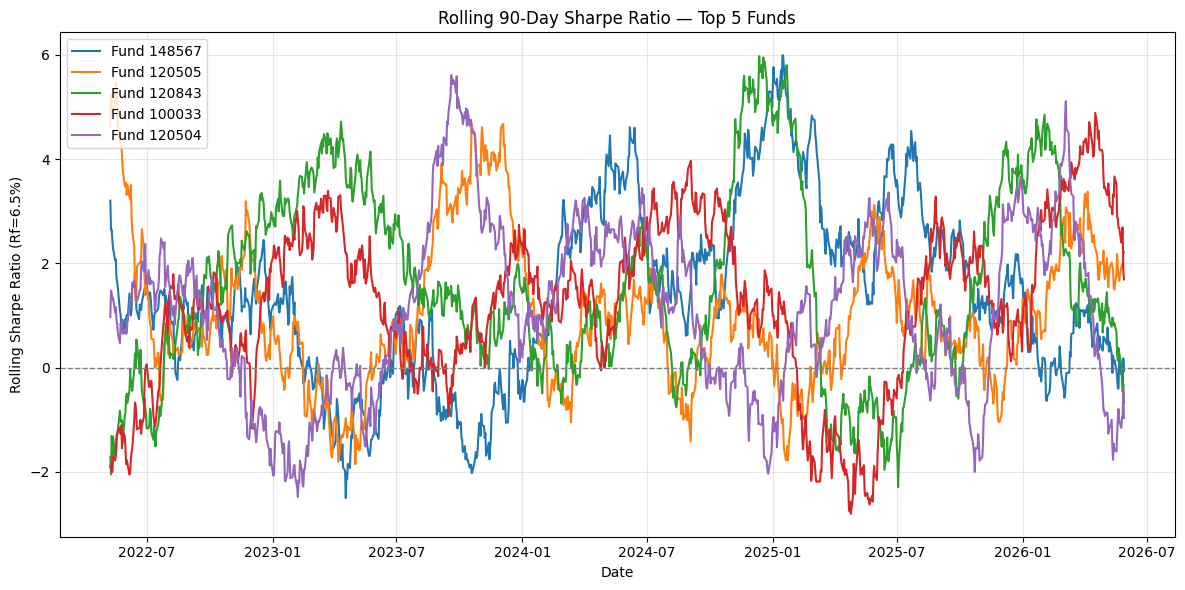

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

for code in top5_codes:
    ax.plot(rolling_sharpe.index, rolling_sharpe[code], label=f"Fund {code}", linewidth=1.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Rolling 90-Day Sharpe Ratio — Top 5 Funds')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe Ratio (Rf=6.5%)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "rolling_sharpe_chart.png", dpi=150)
plt.show()

**Observation:** All 5 top-scored funds show cyclical rolling Sharpe, swinging between roughly 
-2 and +6 repeatedly rather than sustaining consistently high risk-adjusted returns. This 
suggests the strong full-period Sharpe/scorecard rankings from Day 4 reflect strong multi-month 
windows rather than uniformly stable performance — worth noting for any recommendation that 
implies "buy and hold."

In [30]:
txn_check = pd.read_sql("SELECT * FROM fact_transactions LIMIT 5", conn)
print(txn_check.columns.tolist())
txn_check

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,Net Banking,Pending


###  3. Investor Cohort Analysis

In [31]:
txn = pd.read_sql("SELECT * FROM fact_transactions", conn)
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

first_txn = txn.groupby('investor_id')['transaction_date'].min().rename('first_txn_date')
first_txn_year = first_txn.dt.year.rename('cohort_year')

txn = txn.merge(first_txn_year, on='investor_id')

print(txn['cohort_year'].value_counts().sort_index())

cohort_year
2024    32499
2025      279
Name: count, dtype: int64


#### Compute cohort metrics

In [32]:
invest_txn = txn[txn['transaction_type'].isin(['SIP', 'Lumpsum'])]

cohort_avg_sip = invest_txn[invest_txn['transaction_type'] == 'SIP'].groupby('cohort_year')['amount_inr'].mean()
cohort_total_invested = invest_txn.groupby('cohort_year')['amount_inr'].sum()
cohort_top_fund = invest_txn.groupby(['cohort_year', 'amfi_code'])['amount_inr'].sum().reset_index()
cohort_top_fund = cohort_top_fund.loc[cohort_top_fund.groupby('cohort_year')['amount_inr'].idxmax()][['cohort_year', 'amfi_code']].set_index('cohort_year')

cohort_summary = pd.DataFrame({
    'avg_sip_amount': cohort_avg_sip,
    'total_invested': cohort_total_invested,
    'top_fund': cohort_top_fund['amfi_code']
})

print(cohort_summary)

             avg_sip_amount  total_invested top_fund
cohort_year                                         
2024           10996.885825      2258062304   119095
2025           13505.209581        18992635   119094


In [33]:
print(txn['transaction_date'].min(), txn['transaction_date'].max())
print(txn['transaction_date'].dt.year.value_counts().sort_index())

2024-01-01 00:00:00 2025-05-30 00:00:00
transaction_date
2024    23210
2025     9568
Name: count, dtype: int64


**Data scope note:** `fact_transactions` spans Jan 2024–May 2025 only, unlike `fact_nav` and 
`fact_performance` which cover Jan 2022–May 2026. This means cohort analysis by first-transaction 
year only has two real cohorts (2024, 2025), with 2025 being a partial year (5 months) explaining 
the sharp drop in cohort size (32,499 investors in 2024 vs 279 in 2025). This is a genuine 
limitation of the source data, not a processing error — confirmed by checking raw transaction 
date range before grouping.

### 4. SIP continuity analysis

In [34]:
sip_txn = txn[txn['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])

sip_counts = sip_txn.groupby('investor_id').size()
eligible_investors = sip_counts[sip_counts >= 6].index

sip_eligible = sip_txn[sip_txn['investor_id'].isin(eligible_investors)]

def avg_gap(dates):
    return dates.diff().dt.days.mean()

continuity = sip_eligible.groupby('investor_id')['transaction_date'].apply(avg_gap).rename('avg_gap_days')

continuity_df = continuity.reset_index()
continuity_df['at_risk'] = continuity_df['avg_gap_days'] > 35

print(f"Eligible investors (6+ SIPs): {len(eligible_investors)}")
print(continuity_df['at_risk'].value_counts())
print(continuity_df.describe())

Eligible investors (6+ SIPs): 1362
at_risk
True     1332
False      30
Name: count, dtype: int64
       avg_gap_days
count   1362.000000
mean      64.889132
std       15.593199
min       19.800000
25%       53.635417
50%       64.690476
75%       75.575000
max      102.600000


In [35]:
sample_id = eligible_investors[0]
sample_dates = sip_eligible[sip_eligible['investor_id'] == sample_id]['transaction_date'].sort_values()
print(sample_id)
print(sample_dates.tolist())
print(sample_dates.diff().dt.days.tolist())

INV000004
[Timestamp('2024-03-16 00:00:00'), Timestamp('2024-04-11 00:00:00'), Timestamp('2024-05-09 00:00:00'), Timestamp('2024-07-07 00:00:00'), Timestamp('2025-03-29 00:00:00'), Timestamp('2025-05-17 00:00:00')]
[nan, 26.0, 28.0, 59.0, 265.0, 49.0]


**Finding:** 1,332 of 1,362 eligible investors (97.8%) are flagged "at-risk" under avg SIP gap > 
35 days. Spot-checking individual investors (e.g. INV000004: gaps of 26, 28, 59, 265, 49 days) 
shows this is driven by irregular real-world behavior — investors often maintain near-monthly 
SIPs but have one or two long pauses, which pulls the *average* gap above the 35-day threshold 
even when most individual gaps were on-time. This means "at-risk" here should be read as "has 
had at least one significant SIP disruption," not "consistently irregular investor" — a stricter 
metric (e.g. % of individual gaps >35 days, rather than average gap) would separate these two 
very different investor profiles.

### 5. Simple fund recommender

#### sharpe_ratio rebuilt using identical logic to Performance_Analytics.ipynb, for consistency.

In [36]:
# Rebuild Sharpe ratio (same logic as Day 4's Performance_Analytics.ipynb)
Rf_annual = 0.065
trading_days = 252

mean_daily_return = daily_returns_trading.mean()
std_daily_return = daily_returns_trading.std()
Rp_annual = mean_daily_return * trading_days

sharpe_ratio = (Rp_annual - Rf_annual) / (std_daily_return * np.sqrt(trading_days))

print(sharpe_ratio.sort_values(ascending=False).head())

amfi_code
148567    1.448291
120843    1.306744
148569    1.234930
119551    1.208267
120505    1.180101
dtype: float64


In [37]:
import sys
sys.path.append(str(PROJECT_ROOT / "scripts"))
from recommender import get_recommendations

for risk in ['Low', 'Moderate', 'High']:
    print(f"\n--- Recommendations for {risk} risk appetite ---")
    print(get_recommendations(risk, DB_PATH, sharpe_ratio))


--- Recommendations for Low risk appetite ---
   amfi_code                                   scheme_name category  \
14    120507      ICICI Pru Liquid Fund - Regular - Growth     Debt   
23    120844          Kotak Liquid Fund - Regular - Growth     Debt   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth     Debt   

   risk_category  sharpe_ratio  
14           Low      0.495723  
23           Low     -0.088747  
4            Low     -0.226575  

--- Recommendations for Moderate risk appetite ---
   amfi_code                                    scheme_name category  \
34    148567  Mirae Asset Large Cap Fund - Regular - Growth   Equity   
22    120843         Kotak Flexicap Fund - Regular - Growth   Equity   
0     119551      SBI Bluechip Fund - Regular Plan - Growth   Equity   

      risk_category  sharpe_ratio  
34         Moderate      1.448291  
22  Moderately High      1.306744  
0          Moderate      1.208267  

--- Recommendations for High risk appetite ---
   

**Limitation:** For Low risk appetite, only 6 funds exist in that category total, and 2 of the 
top-3 recommended have negative Sharpe ratios (underperformed the 6.5% risk-free rate on a 
risk-adjusted basis). The recommender always returns top_n funds regardless of whether they 
clear a quality bar — with a small candidate pool, this can surface weak options. A production 
version might add a minimum Sharpe threshold rather than always forcing exactly 3 results.

### 6. Sector HHI concentration

In [38]:
RAW_PATH = PROJECT_ROOT / "data" / "raw"

holdings = pd.read_csv(RAW_PATH / "09_portfolio_holdings.csv")
print(holdings.shape)
print(holdings.columns.tolist())
holdings.head()

(322, 8)
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [39]:
equity_funds = pd.read_sql("SELECT amfi_code FROM dim_fund WHERE category = 'Equity'", conn)['amfi_code'].astype(int).tolist()

holdings_equity = holdings[holdings['amfi_code'].isin(equity_funds)].copy()
holdings_equity['weight_frac'] = holdings_equity['weight_pct'] / 100

hhi = holdings_equity.groupby('amfi_code')['weight_frac'].apply(lambda w: (w ** 2).sum())
hhi = hhi.sort_values(ascending=False)

print(f"Equity funds in holdings: {holdings_equity['amfi_code'].nunique()}")
print(hhi)

Equity funds in holdings: 34
amfi_code
119092    0.206448
101207    0.200700
119599    0.174751
102885    0.174709
118632    0.168298
148568    0.167930
120505    0.157570
120506    0.153794
125498    0.152414
120841    0.149680
148569    0.149396
100033    0.147592
149323    0.141621
120503    0.140870
100016    0.139534
148567    0.138584
125497    0.136586
119094    0.136406
118635    0.135944
149322    0.134398
119093    0.130894
102887    0.129805
101206    0.129332
120843    0.128683
120842    0.127439
118633    0.121461
119551    0.118716
149324    0.118677
102886    0.114693
119095    0.109605
120504    0.108674
118634    0.108358
119552    0.108011
119598    0.107349
Name: weight_frac, dtype: float64


**Data note:** Initial join between `dim_fund` (Equity category) and `holdings` returned 0 
matches due to a type mismatch — `amfi_code` was string in the SQL query result but int64 in 
`holdings`. Fixed by casting to int before filtering. Worth checking for the same issue in any 
future joins involving `holdings.amfi_code`.

### 7. Advanced insights 

**1. Riskiest funds are consistent across metrics**
The funds with the worst VaR and CVaR (119599, 119095, 101207, 118634) are the same funds 
that had the worst Max Drawdown back in Day 4. Two different risk metrics agree on which 
funds are the riskiest, which makes this a reliable finding.

**2. Even the best funds have bad stretches**
Looking at the rolling 90-day Sharpe ratio, every one of the top 5 funds swings between 
roughly -2 and +6 over time. None of them stay consistently good. This means their strong 
overall Sharpe ratio comes from a few really strong periods, not steady performance the 
whole time.

**3. Investor data only covers 2024 and 2025**
The transactions table starts in Jan 2024 and ends May 2025, so cohort analysis only has 
two years to work with. 2024 has 32,499 investors' first transactions, but 2025 only has 
279 — that's because 2025 is a partial year (only 5 months of data), not because fewer 
people invested.

**4. Almost every investor gets flagged "at-risk" on SIP continuity, but the metric is misleading**
97.8% of eligible investors (1,332 out of 1,362) get flagged as at-risk under the >35 day 
average gap rule. Checking individual investors shows this happens because one long pause 
(like a 265-day gap) pulls up the average, even if most of their SIPs were paid close to 
on time. So "at-risk" here doesn't always mean the investor is consistently irregular — 
just that they had at least one bad stretch.

**5. Sector concentration and fund quality vary a lot by risk category**
Fund 119092 has the highest sector concentration among equity funds (HHI = 0.206), meaning 
its portfolio is less diversified than others. Also, the Low risk category only has 6 funds 
total, and 2 of the top 3 recommended for "Low" risk appetite actually have negative Sharpe 
ratios — so there aren't many genuinely strong low-risk options in this fund lineup.